# Spotify Unwrapped
How to make songs more popular using interpretable tools and counterfactual analysis

---

# Abstract

In the modern music streaming era, artists and producers often lack quantifiable guidance on which musical characteristics drive a song’s success. This study utilizes the *30000 Spotify Songs* dataset consisting of 32,833 songs sourced from the Spotify API to investigate the relationship between intrinsic audio metadata (e.g. danceability, energy, and loudness) and Spotify’s internal popularity metric. The research follows a structured machine learning pipeline including conducting exploratory data analysis (EDA), preprocessing and scaling features, and training multiple regression models. To ensure the results are actionable, the study employs SHAP (SHapley Additive exPlanations) to interpret feature contributions and DICE (Diverse Counterfactual Explanations) to perform counterfactual analysis. This dual approach allows for the identification of specific changes in a song's audio profile that could potentially increase its predicted popularity score. The findings provide data-driven insights that bridge the gap between creative music production and commercial success in the streaming landscape.

**Highlights**

1. Random Forest performed the best against different regression models in predicting the popularity score of songs.
2. SHAP interpretation revealed that instrumentalness, loudness, and energy are the top features that contribute to a song's popularity score.
3. Counterfactual analysis using DICE showed that adjusting features (i.e. having higher or lower values) can potentially impact a song's popularity score.

**Keywords**

Spotify API, Machine Learning, Popularity Prediction, SHAP, Counterfactual Analysis (DiCE), Interpretability.

# Introduction

## Motivation

The motivation for this study comes from the growing role of data in shaping decisions within the modern music industry. With streaming platforms such as Spotify generating detailed information about how songs are produced, distributed, and consumed, it has become possible to analyze music success using measurable features rather than relying solely on intuition. Despite the abundance of talented artists and well-produced songs, many tracks struggle to achieve high popularity, raising the question of whether certain audio characteristics consistently resonate more with listeners. Artists and record labels often rely heavily on external factors such as marketing campaigns, editorial playlist placement, and social media trends to influence a song’s success.

While these strategies can significantly boost visibility, they do not necessarily address the intrinsic musical characteristics that may contribute to a track’s appeal. The availability of detailed audio features and listener engagement data presents an opportunity to examine whether certain quantifiable song attributes are associated with higher popularity. By analyzing the relationship between these features and popularity scores, this project aims to bridge the gap between creative music production and data-driven insight, helping artists, producers, and industry professionals better understand patterns that may contribute to creating more widely appealing songs and maximizing their potential for commercial success.

## Problem Statement
*What are the top features that affect a song's popularity, and what changes can be made to increase the current popularity score?*

---

In the modern streaming landscape, many songs demonstrate strong musical quality yet achieve only moderate popularity, raising an important question: what truly makes a song become a hit? 

While listeners often attribute success to creativity, timing, or marketing, platforms like Spotify now provide measurable audio features and engagement metrics that allow song performance to be analyzed quantitatively. The challenge is that artists and producers still lack clear, data-driven guidance on which musical characteristics are consistently associated with higher popularity. As a result, many well-produced songs fail to reach wider audiences despite their potential. This project therefore investigates whether specific quantifiable audio features can help explain why some songs become highly popular while others only get moderate popularity, identifying patterns that may contribute to hit-making in the streaming era.

## Scope & Limitations

This study focuses on analyzing the numerical audio metadata of 32,833 songs collected from a 2024 dataset scraped from the Spotify API. The analysis uses quantifiable features such as danceability, energy, loudness, tempo, valence, acousticness, speechiness, and instrumentalness to examine their relationship with song popularity. The popularity variable used in this study is based on Spotify’s internal metric, which reflects a combination of the total number of plays a track has received and how recent those plays are. However, the scope of the analysis is limited to these measurable audio attributes and does not account for other important external factors that may influence a song’s success, such as marketing efforts, playlist placement, artist popularity, social media trends, or cultural context. As a result, the findings should be interpreted as insights into the relationship between audio characteristics and popularity, rather than a complete explanation of what determines a hit song in the broader music industry.

# Data and Methods

## Data Source

The 30,000 Spotify Songs dataset is sourced from [Kaggle](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs/data), featuring a diverse collection of song metadata. The data was as of 2024, and was originally compiled using the [spotifyr](https://www.rcharlie.com/spotifyr/) package, designed to streamline the extraction of information directly from Spotify’s API. Each row in the dataset corresponds to a song, while the columns correspond to the metadata of the song which are described below:

| Variable | Description |
|---|---|
| `track_id` | Song unique ID |
| `track_name` | Song name |
| `track_artist` | Song artist |
| `track_popularity` | Song popularity (0–100), where higher values indicate greater popularity |
| `track_album_id` | Album unique ID |
| `track_album_name` | Song album name |
| `track_album_release_date` | Date when the album was released |
| `playlist_name` | Name of playlist |
| `playlist_id` | Playlist ID |
| `playlist_genre` | Playlist genre |
| `playlist_subgenre` | Playlist subgenre |
| `danceability` | Measure (0.0–1.0) of how suitable a track is for dancing based on tempo, rhythm stability, beat strength, and overall regularity |
| `energy` | Measure (0.0–1.0) of perceived intensity and activity; energetic tracks tend to feel fast, loud, and noisy |
| `key` | Estimated overall key of the track using Pitch Class notation (e.g., 0 = C, 1 = C♯/D♭); -1 indicates no key detected |
| `loudness` | Overall loudness of a track in decibels (dB), averaged across the track; typically ranges from -60 to 0 dB |
| `mode` | Modality of the track: major (1) or minor (0) |
| `speechiness` | Detects presence of spoken words; values >0.66 indicate mostly spoken content, 0.33–0.66 mixed speech and music, <0.33 mostly music |
| `acousticness` | Confidence measure (0.0–1.0) indicating whether the track is acoustic |
| `instrumentalness` | Predicts whether a track contains no vocals; values closer to 1.0 indicate greater likelihood of instrumental content |
| `liveness` | Detects presence of an audience; higher values indicate a greater probability that the track was performed live |
| `valence` | Measure (0.0–1.0) of musical positivity; higher values correspond to more positive or happy-sounding tracks |
| `tempo` | Estimated tempo of the track in beats per minute (BPM) |
| `duration_ms` | Duration of the song in milliseconds |

## Methodology

### Overview

<div style="text-align: center;">
<img src="Methodology_Overview.png" alt="Overview of Methodology" width="700" height="300" />
</div>

<div style="text-align: justify;">
To identify potential changes that may improve a song’s popularity score, it is first necessary to determine the key factors driving the model’s predictions. The analysis begins by loading the dataset and conducting exploratory data analysis to understand the data structure and variable distributions. The data is then preprocessed by identifying the feature variables and target variable, and applying scaling where appropriate. Multiple machine learning models are subsequently trained and evaluated, after which the best-performing model is selected and further refined through hyperparameter tuning. Model interpretability is then examined using SHAP to identify the contribution of each feature to the predicted popularity score. Finally, counterfactual analysis is conducted using DiCE to determine which feature changes could potentially increase a song’s predicted popularity.
</div>

### Step 1. Exploratory Data Analysis

The dataset contains 32833 rows and 23 columns where each row corresponds to a song while the columns correspond to the song metadata. It is worth noting that there are no missing values for `track_popularity`, and the audio features (i.e. `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`) all have a float or integer data type, hence data type conversion is no longer required. Moreover, it can be observed that the distribution of the `track_popularity` has a spike on the 0 mark, while the rest follow a quadratic behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('spotify_songs.csv')
df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [4]:
df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

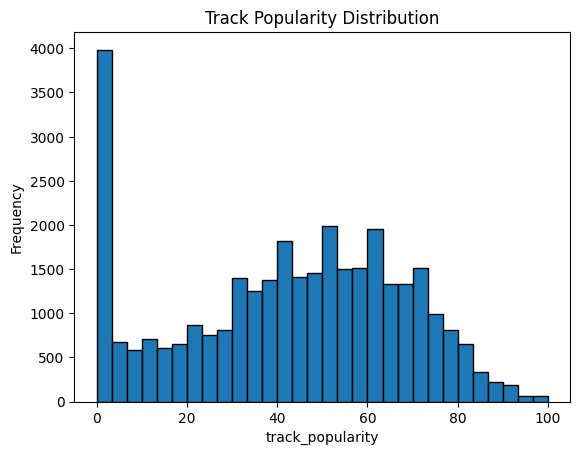

In [5]:
df['track_popularity'].value_counts()

plt.hist(df['track_popularity'], bins=30, edgecolor='black')
plt.title('Track Popularity Distribution')
plt.xlabel('track_popularity')
plt.ylabel('Frequency')
plt.show()

### Step 2. Data Preprocessing

Since we are interested in identifying the features that affect the popularity of songs, we will remove songs that have a `track_popularity` of 0 given that they have no broad appeal. 

In [6]:
# Focus only on track_popularity > 0
df_filtered = df[df['track_popularity'] > 0]
df_filtered

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [7]:
df_filtered.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000,30130.000000
mean,46.287753,0.656072,0.694330,5.356986,-6.723034,0.566578,0.106867,0.179652,0.080745,0.188097,0.510071,120.816084,223912.777232
std,22.445727,0.145054,0.180924,3.612914,2.978582,0.495556,0.101107,0.221496,0.219575,0.151531,0.232221,27.036573,58734.546476
min,1.000000,0.077100,0.000175,0.000000,-46.448000,0.000000,0.022400,0.000001,0.000000,0.009360,0.000010,35.477000,31429.000000
25%,31.000000,0.564000,0.577000,2.000000,-8.164000,0.000000,0.040900,0.016500,0.000000,0.092700,0.331000,99.935250,186854.000000
50%,48.000000,0.673000,0.716000,6.000000,-6.173500,1.000000,0.062400,0.084800,0.000014,0.126000,0.511000,121.618500,214624.500000
75%,63.000000,0.762000,0.836000,9.000000,-4.660000,1.000000,0.132000,0.263000,0.003958,0.244000,0.692000,134.020250,251034.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [8]:
# Prepare features: include genre and numeric variables

column_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
X = df_filtered.loc[:, column_features]
# X = df_dummies.drop(columns='track_popularity')
y = df_filtered['track_popularity']

# Perform train, test, split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 3. Train ML Models

Different regression models are trained on the dataset and are compared against each other based on the Root Mean Square Error (RMSE) which measures the average magnitude of error between predicted and observed values. Hyperparameter tuning will then be performed to identify the best parameters for the selected model.

In [9]:
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Setup Models
models = {
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

results_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Perform Cross-Validation
scoring_metrics = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']

for name, model in models.items():
    start_time = time.time()
    
    # Note: n_jobs=-1 might conflict with CatBoost/LightGBM internal threading 
    # but generally works fine for this scale
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=kf, 
                                scoring=scoring_metrics, n_jobs=-1)
    
    end_time = time.time()
    
    results_list.append({
        'Model': name,
        'CV RMSE': abs(cv_results['test_neg_root_mean_squared_error'].mean()),
        'CV MAE': abs(cv_results['test_neg_mean_absolute_error'].mean()),
        'Run Time (sec)': end_time - start_time
    })

# 3. Display Results Summary (Sorted by lowest MAE to address your goal)
results_df = pd.DataFrame(results_list).sort_values(by='CV MAE', ascending=True)
print("--- Training Results (Cross-Validation) ---")
print(results_df)

# 4. Evaluate the Best Model on the Test Set
best_model_name = results_df.iloc[0]['Model']
best_model_instance = models[best_model_name]

# Fit the best model on the ENTIRE training set
best_model_instance.fit(X_train_scaled, y_train)

# Predict on the "Unseen" Test Set
test_predictions = best_model_instance.predict(X_test_scaled).astype(int)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_mae = mean_absolute_error(y_test, test_predictions)

print(f"\nFinal Test Scores for {best_model_name}:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")

--- Training Results (Cross-Validation) ---
               Model    CV RMSE     CV MAE  Run Time (sec)
6      Random Forest  19.185430  14.800627       15.562027
7            XGBoost  20.722493  16.653874        1.841852
9           CatBoost  20.592144  16.767096        3.419682
8           LightGBM  20.817324  17.046487        2.499646
1                SVR  21.690181  17.505606       13.019283
2  Linear Regression  21.799498  17.928953        1.616548
3              Ridge  21.799495  17.928965        0.133195
4              Lasso  21.982228  18.128317        0.132479
0                KNN  22.772482  18.222541        2.156205
5      Decision Tree  26.430069  19.098650        1.771796

Final Test Scores for Random Forest:
RMSE: 18.6916
MAE:  14.2489


Based on an initial run, Random Forest performs the best across other models. Moreover, the RMSE of Random Forest (i.e. 18.70) is lower than the standard deviation of the `track_popularity` (i.e. 22.45) suggesting that the model performs better than randomly guessing the mean for every single track. Consequently, Random Forest will be tuned to get the best hyperparameters.

#### Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

# 1. Define the model
rf = RandomForestRegressor(random_state=42)

# 2. Define the Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2', None], # None uses all features
    'min_samples_split': [2, 5, 10]
}

# 3. Initialize GridSearchCV
# We use neg_root_mean_squared_error as the primary refit metric
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# 4. Fit on the training data (using your scaled versions)
print("Starting Grid Search for Random Forest...")
grid_search.fit(X_train_scaled, y_train)

# 5. Best results
best_rf = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

# 6. Final Evaluation on Test Set
test_predictions = best_rf.predict(X_test_scaled).astype(int)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_mae = mean_absolute_error(y_test, test_predictions)

print(f"\n[OPTIMIZED RANDOM FOREST RESULTS]")
print(f"Test RMSE: {final_rmse:.4f}")
print(f"Test MAE:  {final_mae:.4f}")

Starting Grid Search for Random Forest...

Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

[OPTIMIZED RANDOM FOREST RESULTS]
Test RMSE: 18.5750
Test MAE:  14.2738


#### Model Performance

The plot below shows that the model demonstrates a strong ability to identify high-popularity 'hits,' where predictions closely align with actual values. However, it exhibits significant bias in the lower popularity ranges, frequently over-predicting the success of tracks that ultimately fail.

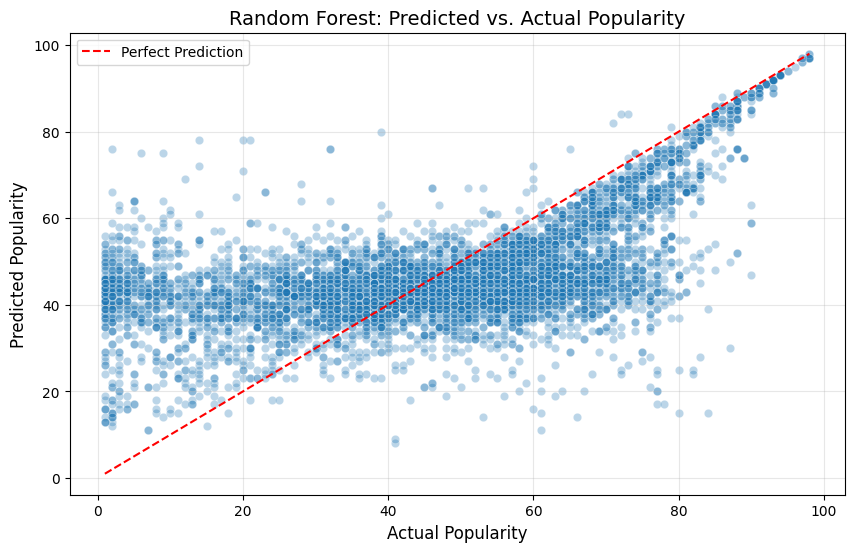

In [11]:
def plot_regression_performance(model, X_test, y_test):
    """
    Plots Predicted vs Actual values to visualize regression performance.
    """
    import seaborn as sns
    predictions = model.predict(X_test).astype(int)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
    
    # Add a 45-degree line (Perfect Prediction Line)
    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, color='red', linestyle='--', label='Perfect Prediction')
    
    plt.title('Random Forest: Predicted vs. Actual Popularity', fontsize=14)
    plt.xlabel('Actual Popularity', fontsize=12)
    plt.ylabel('Predicted Popularity', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_regression_performance(best_rf, X_test_scaled, y_test)

For the residual plot, the presence of heteroscedasticity in the residuals suggests that while audio features are a valid signal for success, they are insufficient for distinguishing between low and mid-range popularity. However, since the objective of the study is to understand the audio features associated with popular songs, and the model demonstrates strong predictive capability in identifying songs with high popularity, this limitation will be considered acceptable.

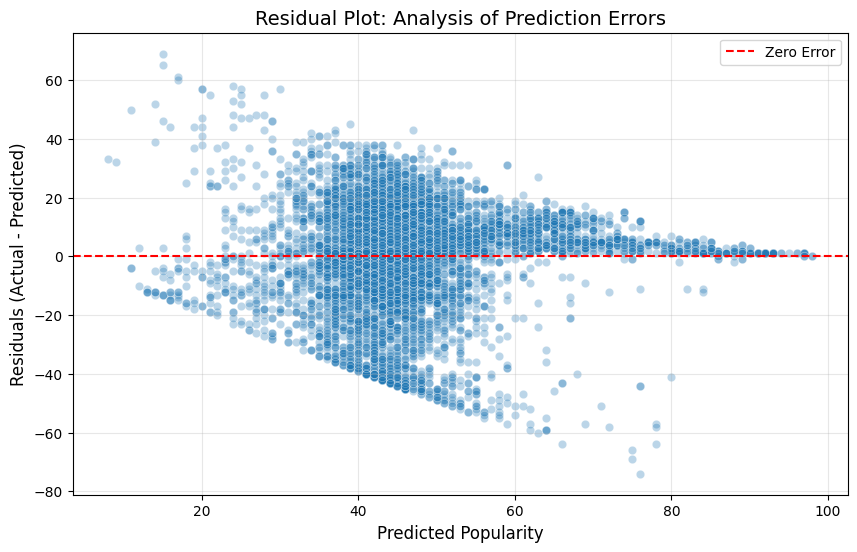

In [12]:
def plot_residuals(model, X_test, y_test):
    """
    Plots the residuals to check for heteroscedasticity and bias.
    """
    import seaborn as sns
    predictions = model.predict(X_test).astype(int)
    residuals = y_test - predictions
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=predictions, y=residuals, alpha=0.3)
    
    # Add a horizontal line at 0
    plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')
    
    plt.title('Residual Plot: Analysis of Prediction Errors', fontsize=14)
    plt.xlabel('Predicted Popularity', fontsize=12)
    plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_residuals(best_rf, X_test_scaled, y_test)

### Step 4. SHAP Interpretations

Given that SHAP can be computationally expensive, we get a representative sample of the test set and apply SHAP on the representative sample.

To identify the appropriate sample size, we use Cochran's sample size formula given by 

$$
n_0 = \frac{Z^2 \, p (1 - p)}{e^2}
$$
where:

- $n_0$ = required sample size  
- $Z$ = Z-score corresponding to the desired confidence level  
- $p$ = estimated proportion of the population with the attribute  
- $e$ = desired level of precision (margin of error)

Since the total size of the test set is known, we adjust the sample size by the finite population correction given by

$$
n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}
$$
where:

- $n$ = adjusted sample size  
- $n_0$ = initial sample size from Cochran's formula  
- $N$ = population size

For this study, the Z-score $Z$, estimated population proportion $p$, and margin of error $e$ will be set to 1.96 (for 95% confidence), 0.5, and 0.05 accordingly (Ahmed, 2024).

‌

In [13]:
# Identify sample size

z_score = 1.96 # for 95% confidence
p = 0.5 # suggested proportion
margin_of_error = 0.05

initial_sample_size = (z_score**2 * p * (1 - p)) / margin_of_error**2

adjusted_sample_size = round(initial_sample_size / (1 + ((initial_sample_size - 1) / len(X_test_scaled))))
print(f'Sample Size: {adjusted_sample_size}')

Sample Size: 361


Trying SHAP with 361 samples.

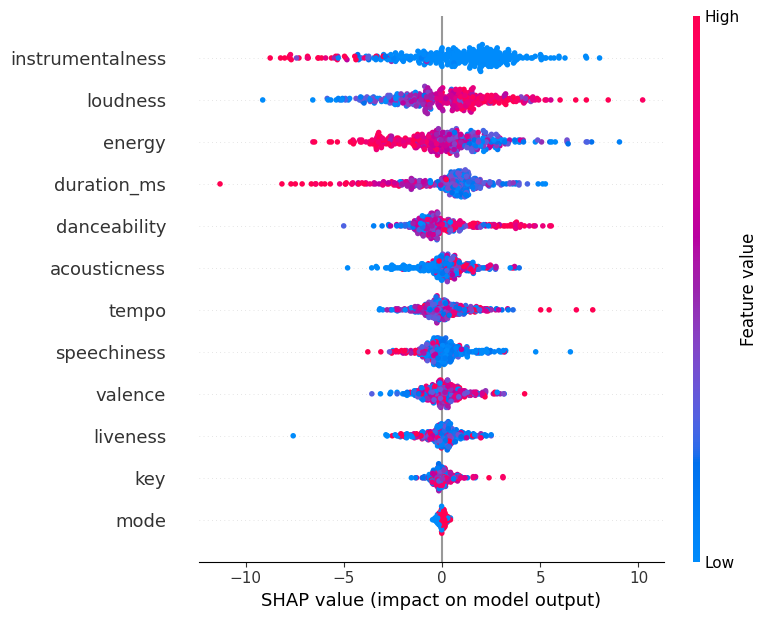

In [14]:
import shap

# Convert the NumPy array back to a DataFrame so we can use .sample()
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Generate random samples
X_test_sample = X_test_df.sample(n=adjusted_sample_size, random_state=42)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Plot
shap.summary_plot(shap_values, X_test_sample)

Looking at the global feature contributions, instrumentalness, loudness, and energy are the top 3 contributing features.

To check the consistency of the results, we try SHAP with varying sample sizes. Below is the SHAP implementation with 600 samples.

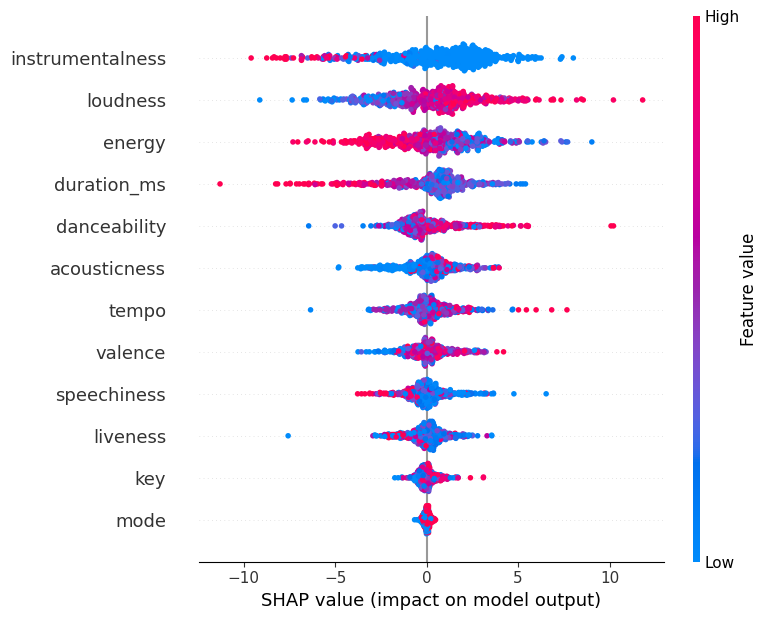

In [15]:
import shap

# Convert the NumPy array back to a DataFrame so we can use .sample()
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Generate random samples
X_test_sample = X_test_df.sample(n=600, random_state=42)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Plot
shap.summary_plot(shap_values, X_test_sample)

Trying SHAP with 1000 samples.

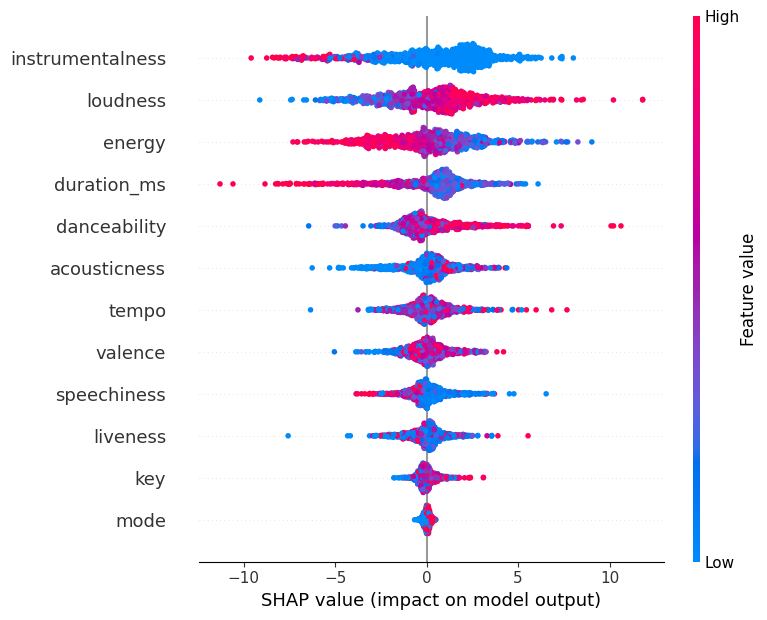

In [16]:
import shap

# Convert the NumPy array back to a DataFrame so we can use .sample()
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Generate random samples
X_test_sample = X_test_df.sample(n=1000, random_state=42)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Plot
shap.summary_plot(shap_values, X_test_sample)

Looking at the SHAP results using 600 and 1000 samples, the results remain consistent except for the bottom part that includes valence, speechiness, and liveness.

### Step 5. Diverse Counterfactual Explanations (DICE)

After identifying the feature contributions, we can now perform counterfactual analysis using Diverse Counterfactual Explanations (DICE) with the goal of understanding what features can be modified to increase the popularity score.

#### Prepare the DICE Model

In [17]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_split=2, n_estimators=300))
])

pipe.fit(X_train, y_train);

In [18]:
def counterfactuals(track_index):
    import dice_ml
    from dice_ml.utils import helpers  # Import DICE helpers

    # DICE setup
    # Convert the pandas dataframe to a proper format for DICE
    # This assumes that X_train and X_test are already processed and normalized by the pipeline
    feature_names = X_train.columns.tolist()
    target_name = 'track_popularity'

    # Initialize DICE data and model objects
    data_dice = dice_ml.Data(dataframe=pd.concat([X, y], axis=1), continuous_features=feature_names, outcome_name=target_name)
    model_dice = dice_ml.Model(model=pipe, backend="sklearn", model_type='regressor')

    # Create a DICE explainer instance
    dice_explainer = dice_ml.Dice(data_dice, model_dice)

    # Generate counterfactuals for the track_index in X_test
    query_instance = X_test.loc[[track_index]]  # Get the track's features

    # Show the initial state of the track (original prediction)
    initial_prediction = pipe.predict(query_instance).astype(int)
    print(f"Initial Prediction for track {track_index}: {initial_prediction[0]}")

    # Display the track's feature values
    print("\nFeature values of the chosen track:")
    print(query_instance)

    # Generate 5 counterfactual explanations to flip the class
    counterfactuals = dice_explainer.generate_counterfactuals(query_instance, total_CFs=5, sample_size=5000, desired_range=[initial_prediction[0] + 10, 100])

    # Display the counterfactuals
    print("\nCounterfactuals to flip the prediction:")
    print(counterfactuals.cf_examples_list[0].final_cfs_df)


#### Generate Counterfactuals

We look at the following artists as an example:


|track_index|track_name|track_artist|track_popularity|
|---|---|---|---|
|259|Sing It With Me - Embody Remix|JP Cooper|50|
|29755|Perfect - Mike Perry Remix|Ed Sheeran|46|
|2231|Save As Draft|Katy Perry|50|
|31193|Freedom|David Guetta|38|
|29665|Good Thing (feat. Kehlani) - Marc Benjamin Remix|Zedd|50|

For JP Cooper, we can generate counterfactuals for the track "Sing It With Me - Embody Remix" that currently has a popularity score of 50.

In [19]:
counterfactuals(259)

Initial Prediction for track 259: 51

Feature values of the chosen track:
     danceability  energy  key  loudness  mode  speechiness  acousticness  \
259         0.674   0.854    5    -5.253     1        0.115         0.054   

     instrumentalness  liveness  valence    tempo  duration_ms  
259               0.0     0.379    0.503  111.969       180571  


100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


Counterfactuals to flip the prediction:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.887   0.506    5    -5.253     1        0.115         0.054   
1         0.674   0.310    5    -5.253     1        0.115         0.958   
2         0.674   0.462    5    -5.253     1        0.115         0.923   
3         0.674   0.078    5    -5.253     1        0.115         0.854   
4         0.674   0.272    5    -5.253     1        0.115         0.842   

   instrumentalness  liveness  valence    tempo  duration_ms  track_popularity  
0               0.0     0.379    0.503  111.969       180571              61.0  
1               0.0     0.379    0.503  111.969       180571              63.0  
2               0.0     0.379    0.503  111.969       180571              63.0  
3               0.0     0.379    0.503  111.969       180571              61.0  
4               0.0     0.379    0.503  111.969       180571              62.0  


For Ed Sheeran, we can generate counterfactuals for the track "Perfect - Mike Perry Remix" that currently has a popularity score of 46.

In [20]:
counterfactuals(29755)

Initial Prediction for track 29755: 50

Feature values of the chosen track:
       danceability  energy  key  loudness  mode  speechiness  acousticness  \
29755         0.732   0.756    5    -4.309     0       0.0324          0.26   

       instrumentalness  liveness  valence   tempo  duration_ms  
29755               0.0      0.13    0.343  113.98       221333  


100%|██████████| 1/1 [00:03<00:00,  3.67s/it]


Counterfactuals to flip the prediction:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.732   0.086   11    -4.309     0       0.0324         0.991   
1         0.732   0.297    5    -4.309     0       0.0870         0.608   
2         0.732   0.086   11    -4.309     0       0.0760         0.991   
3         0.732   0.297    5    -4.309     1       0.0870         0.608   

   instrumentalness  liveness  valence   tempo  duration_ms  track_popularity  
0               0.0      0.13    0.343  113.98       155359              61.0  
1               0.0      0.13    0.430  113.98       175329              61.0  
2               0.0      0.13    0.343  113.98       155359              62.0  
3               0.0      0.13    0.430  113.98       175329              62.0  


For Katy Perry, we can generate counterfactuals for the track "Save As Draft" that currently has a popularity score of 50.

In [21]:
counterfactuals(2231)

Initial Prediction for track 2231: 50

Feature values of the chosen track:
      danceability  energy  key  loudness  mode  speechiness  acousticness  \
2231          0.59   0.565    9    -7.231     1       0.0484         0.348   

      instrumentalness  liveness  valence   tempo  duration_ms  
2231               0.0     0.109   0.0519  131.76       228653  


100%|██████████| 1/1 [00:03<00:00,  3.49s/it]


Counterfactuals to flip the prediction:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.759   0.565    6    -7.231     1       0.0484         0.348   
1         0.809   0.285    4    -7.231     0       0.0910         0.985   
2         0.809   0.285    4    -7.231     0       0.0910         0.985   
3         0.555   0.510   11    -3.310     1       0.0484         0.857   

   instrumentalness  liveness  valence    tempo  duration_ms  track_popularity  
0               0.0     0.444     0.71  131.760       179494              61.0  
1               0.0     0.109     0.77  131.760       228653              61.0  
2               0.0     0.116     0.77  131.760       228653              61.0  
3               0.0     0.109     0.41   91.206       183079              62.0  


For David Guetta, we can generate counterfactuals for the track "Freedom" that currently has a popularity score of 38.

In [22]:
counterfactuals(31193)

Initial Prediction for track 31193: 42

Feature values of the chosen track:
       danceability  energy  key  loudness  mode  speechiness  acousticness  \
31193         0.456   0.802    7    -7.173     1       0.0962       0.00266   

       instrumentalness  liveness  valence    tempo  duration_ms  
31193              0.37     0.122   0.0616  116.497       235160  


100%|██████████| 1/1 [00:01<00:00,  1.27s/it]


Counterfactuals to flip the prediction:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.456   0.066    6   -14.640     0       0.0962         0.904   
1         0.456   0.227    7   -10.936     1       0.0962         0.962   
2         0.456   0.241    7   -25.633     1       0.0962         0.949   
3         0.456   0.288    7    -7.173     1       0.0962         0.945   
4         0.456   0.057    7   -44.475     1       0.0962         0.943   

   instrumentalness  liveness  valence    tempo  duration_ms  track_popularity  
0              0.37     0.122   0.0616  116.497       235160              54.0  
1              0.30     0.122   0.0616  116.497       235160              54.0  
2              0.30     0.122   0.0616  116.497       235160              52.0  
3              0.00     0.060   0.0616  116.497       235160              55.0  
4              0.37     0.122   0.0616  116.497       235160              53.0  


For Zedd, we can generate counterfactuals for the track "Good Thing (feat. Kehlani) - Marc Benjamin Remix" that currently has a popularity score of 50.

In [24]:
counterfactuals(29665)

Initial Prediction for track 29665: 46

Feature values of the chosen track:
       danceability  energy  key  loudness  mode  speechiness  acousticness  \
29665         0.494   0.817    1    -7.631     0        0.175         0.105   

       instrumentalness  liveness  valence    tempo  duration_ms  
29665           0.00217     0.207    0.187  127.915       225000  


100%|██████████| 1/1 [00:01<00:00,  1.97s/it]


Counterfactuals to flip the prediction:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.494   0.382    1    -7.631     0        0.175         0.740   
1         0.494   0.382    3    -7.631     0        0.175         0.740   
2         0.494   0.177    1    -7.631     1        0.175         0.994   
3         0.494   0.345    1    -7.631     0        0.084         0.105   
4         0.494   0.177    1    -7.631     1        0.175         0.994   

   instrumentalness  liveness  valence    tempo  duration_ms  track_popularity  
0               0.0     0.207    0.187  127.915       225000              58.0  
1               0.0     0.207    0.187  127.915       225000              58.0  
2               0.0     0.207    0.187   45.416       225000              60.0  
3               0.0     0.207    0.090  127.915       221593              57.0  
4               0.0     0.207    0.010   45.416       225000              60.0  


# Results and Discussion

**Model Selection**

Different regression models were trained on the Spotify dataset, and **Random Forest** performed the best with an RMSE of 18.575 which is lower than the standard deviation of the `track_popularity` at 22.45. Although this suggests that the model performs better than randomly guessing the mean for every single track, the residual plot shows that the model struggles with distinguising between low and mid-range popularity. As previously noted, the model’s performance will still be considered adequate, as the primary objective of the study is to identify the audio features associated with popular songs, and the model demonstrates strong predictive capability in identifying songs with high popularity.

**SHAP Interpretation**

Using Random Forest as the model of choice, the feature contributions were analyzed with SHAP. Since the test set has over 6000 rows, performing SHAP on all datapoints may be computationally expensive. As such, random sampling was performed with varying sample sizes to check consistency of results. Using 361 samples, 600 samples, and 1000 samples, the results show that the top 3 features with the highest contributions to `track_popularity` are instrumentalness, loudness, and energy. 


1. Instrumentalness: High values are almost all on the left side of the zero line suggesting that the more "instrumental" a song is (less vocals), the more the model penalizes its popularity score. Conversely, lower values contribute positively to the prediction sugesting that the less "instrumental" a song is the more it contributes to the popularity score. 

2. Loudness: High values are mostly on the right side suggesting that louder songs tend to have a higher popularity score.

3. Energy: High energy can either push a song up or pull it down, however majority of the high values are on the left suggesting that "too much" energy might contribute negatively for general popularity in this specific dataset.

**Counterfactual Analysis**

Diverse Counterfactual Explanations (DICE) was used to look at *what-if* scenarios for certain tracks. As previously mentioned, the following examples were considered:

|track_index|track_name|track_artist|track_popularity|
|---|---|---|---|
|259|Sing It With Me - Embody Remix|JP Cooper|50|
|29755|Perfect - Mike Perry Remix|Ed Sheeran|46|
|2231|Save As Draft|Katy Perry|50|
|31193|Freedom|David Guetta|38|
|29665|Good Thing (feat. Kehlani) - Marc Benjamin Remix|Zedd|50|

For JP Cooper's "Sing It With Me - Embody Remix", the Random Forest model made an initial prediction of 51 for its popularity score. Using counterfactual analysis, increasing the acousticness of the song and lowering its energy can increase its popularity score to aroud 10 points. These are aligned with the results from SHAP wherein higher values of acousticness and lower levels of energy have a positive impact on the popularity score.

For Ed Sheeran's "Perfect - Mike Perry Remix", the Random Forest model made an initial prediction of 50 for its popularity score. Using counterfactual analysis, decreasing its duration, increasing its acousticness, increasing the speechiness increasing the key and lowering the energy can increase its popularity score to around 10 points. These are also consistent with the results from SHAP except for the speechiness. It is worth noting however that speechiness is on the lower end of the top contributing features of popularity score.

For Katy Perry's "Save As Draft", the Random Forest Model made an initial prediction of 50 for its popularity score. Using counterfactual analysis, decreasing its duration, decreasing the tempo, increasing the valence, increasing the acousticness, increasing the loudness, increasing the key, and lowering the energy can increase its popularity score by 10 points. Similar to the earlier examples, these are aligned with the results from SHAP.

For David Guetta's "Freedom", the Random Forest Model made an initial prediction of 42 for its popularity score. Using counterfactual analysis, lowering its liveness, instrumentalness and energy, as well as increasing its acousticness can increase its popularity score by 10 points. Likewise, these are also aligned with the results from SHAP.

Lastly, Zedd's "Good Thing (feat. Kehlani) - Marc Benjamin Remix" had an initial prediction of 46 for its popularity score. Using counterfactual analysis, lowering the instrumentalness, increasing its acousticness, and lowering its energy can increase its popularity score by 10 points. As with previous examples, these are aligned with the results from SHAP.


# Conclusion

The analysis suggests that several measurable audio characteristics: the presence of vocals, higher loudness levels, and controlled energy are associated with higher song popularity. These findings provide artists and producers with data-driven insights into how certain musical attributes may align with listener preferences as reflected in Spotify audio metrics. For instance, songs that emphasize vocals, maintain fuller loudness levels, and avoid excessively high energy levels may have a broader appeal to listeners. While these features do not guarantee a hit, they highlight patterns that can help guide creative and production decisions when developing new songs or albums.

At the same time, song success in the music industry remains strongly influenced by many external factors beyond audio characteristics, including marketing strategies, artist branding, audience targeting, and cultural trends. Therefore, the results of this study should not be interpreted as strict rules for producing popular songs, but rather as analytical insights that can complement music production and industry strategy. By combining creative vision with data-informed understanding of listener preferences, artists and producers may be better positioned to maximize the potential reach and popularity of their music.


# Recommendations

To further enrich the study, additional features may be incorporated to provide a more comprehensive understanding of the factors influencing song popularity. These may include variables related to the artist and listener engagement such as artist follower count, artist status (e.g., major label or independent), user engagement metrics (e.g. likes and shares), and whether a track is marked as explicit. Including these variables may help capture dimensions of popularity that extend beyond audio characteristics alone.

In addition, the album or track release date may be incorporated as a feature to examine temporal patterns in music popularity. Conducting a time-series analysis could help identify shifts in listener preferences over time and reveal emerging trends in audio characteristics. This approach may also enable the exploration of trend forecasting, allowing researchers to predict which musical attributes are more likely to become popular in the future.

# References

[1] Ahmed, S. K. (2024). Research methodology simplified: How to choose the right sampling technique and determine the appropriate sample size for research. Oral Oncology Reports, 12(100662), 1–7. https://doi.org/10.1016/j.oor.2024.100662

[2] Joakim Arvidsson. (2026). 30000 Spotify Songs. Kaggle.com. https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs/data?select=readme.md

[3] Spotify. (2025). Web API Reference | Spotify for Developers. Developer.spotify.com. https://developer.spotify.com/documentation/web-api/reference/get-audio-features

[4] Web API Reference | Spotify for Developers. (n.d.). Developer.spotify.com. https://developer.spotify.com/documentation/web-api/reference/get-an-artists-top-tracks